In [13]:
import sys, os, json
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Get paths
current_dir = os.getcwd()
parent_dir  = os.path.dirname(current_dir)
src_path    = os.path.join(parent_dir, 'src')

# Add ALL folders directly to Python path
folders = ['parsers', 'extractors', 'validators',
           'models', 'synthesis', 'recommendations',
           'orchestrator', 'report']

for folder in folders:
    full_path = os.path.join(src_path, folder)
    if full_path not in sys.path:
        sys.path.insert(0, full_path)

# Also add src itself
sys.path.insert(0, src_path)

# Verify paths
print("Checking folders:")
for folder in folders:
    full_path = os.path.join(src_path, folder)
    exists = os.path.exists(full_path)
    print(f"  {folder}: {'✓ EXISTS' if exists else '✗ MISSING'}")
    if exists:
        files = os.listdir(full_path)
        print(f"    Files: {files}")

print("\nPython path added successfully!")

Checking folders:
  parsers: ✓ EXISTS
    Files: ['input_parser.py', '__init__.py', '__pycache__']
  extractors: ✓ EXISTS
    Files: ['data_extractor.py', '__init__.py', '__pycache__']
  validators: ✓ EXISTS
    Files: ['data_validator.py', '__init__.py', '__pycache__']
  models: ✓ EXISTS
    Files: ['parameter_interpreter.py', 'pattern_recognition.py', '__init__.py', '__pycache__']
  synthesis: ✓ EXISTS
    Files: ['findings_synthesizer.py', '__init__.py', '__pycache__']
  recommendations: ✓ EXISTS
    Files: ['recommendation_generator.py', '__init__.py', '__pycache__']
  orchestrator: ✓ EXISTS
    Files: ['orchestrator.py', '__init__.py', '__pycache__']
  report: ✓ EXISTS
    Files: ['report_generator.py', '__init__.py', '__pycache__']

Python path added successfully!


In [14]:
# Import modules directly by file path - bypasses ALL module issues
import importlib.util

def load_module_from_file(module_name, file_path):
    """Load a Python file directly - no __init__.py needed"""
    spec   = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

# Define file paths
src = os.path.join(os.path.dirname(os.getcwd()), 'src')

files = {
    'input_parser':            os.path.join(src, 'parsers',         'input_parser.py'),
    'data_extractor':          os.path.join(src, 'extractors',      'data_extractor.py'),
    'data_validator':          os.path.join(src, 'validators',      'data_validator.py'),
    'parameter_interpreter':   os.path.join(src, 'models',          'parameter_interpreter.py'),
    'pattern_recognition':     os.path.join(src, 'models',          'pattern_recognition.py'),
    'findings_synthesizer':    os.path.join(src, 'synthesis',       'findings_synthesizer.py'),
    'recommendation_generator':os.path.join(src, 'recommendations', 'recommendation_generator.py'),
    'orchestrator':            os.path.join(src, 'orchestrator',    'orchestrator.py'),
    'report_generator':        os.path.join(src, 'report',          'report_generator.py'),
}

# Load each module
loaded = {}
for name, path in files.items():
    if os.path.exists(path):
        try:
            loaded[name] = load_module_from_file(name, path)
            print(f"✓ Loaded: {name}")
        except Exception as e:
            print(f"✗ Failed: {name} → {e}")
    else:
        print(f"✗ File not found: {path}")

print("\nAll modules loaded!")

✓ Loaded: input_parser
✓ Loaded: data_extractor
✓ Loaded: data_validator
✓ Loaded: parameter_interpreter
✓ Loaded: pattern_recognition
✓ Loaded: findings_synthesizer
✓ Loaded: recommendation_generator
✓ Loaded: orchestrator
✓ Loaded: report_generator

All modules loaded!


In [15]:
# Cell 3 - Run complete pipeline on one report
from pathlib import Path

test_file = Path('../data/raw/report_001.json')

# Check file exists first
if not test_file.exists():
    print("File not found! Running dataset generator...")
    import subprocess
    subprocess.run(['python', '../create_dataset.py'])
    print("Dataset created!")

print(f"Processing: {test_file}")
print("-" * 60)

try:
    report = orchestrator.process_report(str(test_file))
    print("="*60)
    print("END-TO-END PIPELINE TEST - SUCCESS")
    print("="*60)
    print(f"\nReport ID : {report['metadata']['report_id']}")
    print(f"Patient   : {report['metadata']['patient_id']}")
    print(f"Status    : {report['overall_status'].upper()}")
    print(f"Time (s)  : {report['metadata']['processing_time']}")

    summary = report.get('parameter_summary', {})
    print(f"\nParameter Summary:")
    print(f"  Total     : {summary.get('total_parameters', 0)}")
    print(f"  Normal    : {summary.get('normal', 0)}")
    print(f"  Abnormal  : {summary.get('abnormal', 0)}")
    print(f"  Borderline: {summary.get('borderline', 0)}")
    print(f"  Critical  : {summary.get('critical', 0)}")

    total_recs = sum(
        len(v) for v in report['recommendations'].values()
        if isinstance(v, list)
    )
    print(f"\nPatterns found   : {len(report['pattern_analysis'].get('patterns', []))}")
    print(f"Recommendations  : {total_recs}")
    print("\n✓ report variable is ready for Cell 4!")

except Exception as e:
    print(f"\n✗ Pipeline failed: {e}")
    import traceback
    traceback.print_exc()
    report = None
    print("\nFix the error above before running Cell 4!")

INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 0 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 2 recommendations
INFO:orchestrator:✓ Done in 0.007s


Processing: ..\data\raw\report_001.json
------------------------------------------------------------
END-TO-END PIPELINE TEST - SUCCESS

Report ID : RPT00001
Patient   : PAT46048
Status    : HEALTHY
Time (s)  : 0.007

Parameter Summary:
  Total     : 15
  Normal    : 15
  Abnormal  : 0
  Borderline: 0
  Critical  : 0

Patterns found   : 0
Recommendations  : 2

✓ report variable is ready for Cell 4!


In [17]:
if report is None:
    print("✗ ERROR: report is None")
    print("Go back and fix Cell 3 first!")
else:
    print("✓ Report variable found, generating files...")

    # Create outputs directory
    outputs_dir = Path('../outputs')
    outputs_dir.mkdir(exist_ok=True)

    html_path = outputs_dir / 'test_report_m4.html'
    json_path = outputs_dir / 'test_report_m4.json'

    try:
        # Generate HTML report
        report_gen.generate_html_report(report, str(html_path))
        print(f"✓ HTML report saved : {html_path}")

        # Save JSON report
        orchestrator.save_report(report, str(json_path))
        print(f"✓ JSON report saved : {json_path}")

        print("\n" + "="*60)
        print("REPORTS GENERATED SUCCESSFULLY")
        print("="*60)
        print(f"\nTo view the HTML report:")
        print(f"  1. Open File Explorer")
        print(f"  2. Navigate to: health_diagnostics_ai/outputs/")
        print(f"  3. Double-click: test_report_m4.html")
        print(f"  4. It opens in your browser!")

    except Exception as e:
        print(f"✗ Failed to generate report: {e}")
        import traceback
        traceback.print_exc()

INFO:report_generator:HTML report saved: ..\outputs\test_report_m4.html


✓ Report variable found, generating files...
✓ HTML report saved : ..\outputs\test_report_m4.html
✓ JSON report saved : ..\outputs\test_report_m4.json

REPORTS GENERATED SUCCESSFULLY

To view the HTML report:
  1. Open File Explorer
  2. Navigate to: health_diagnostics_ai/outputs/
  3. Double-click: test_report_m4.html
  4. It opens in your browser!


In [18]:
test_files = sorted(Path('../data/raw').glob('report_*.json'))

results, errors = [], []

print("Processing all 20 reports with complete pipeline…")
print("-"*60)

for i, tf in enumerate(test_files, 1):
    try:
        r = orchestrator.process_report(str(tf))

        # Save individual HTML report
        rid  = r['metadata']['report_id']
        html = outputs_dir / f'{rid}_m4.html'
        report_gen.generate_html_report(r, str(html))

        total_recs = sum(
            len(v) for v in r['recommendations'].values()
            if isinstance(v, list)
        )
        results.append({
            'file':            tf.name,
            'report_id':       rid,
            'overall_status':  r['overall_status'],
            'total_params':    r['parameter_summary'].get('total_parameters',0),
            'normal':          r['parameter_summary'].get('normal',0),
            'abnormal':        r['parameter_summary'].get('abnormal',0),
            'critical':        r['parameter_summary'].get('critical',0),
            'patterns_found':  len(r['pattern_analysis'].get('patterns',[])),
            'risk_scores':     len(r['pattern_analysis'].get('risk_scores',{})),
            'recommendations': total_recs,
            'processing_time': r['metadata']['processing_time'],
            'html_saved':      True
        })
        print(f"✓ {i:02d}/20  {tf.name}  →  {r['overall_status']}")

    except Exception as e:
        errors.append({'file': tf.name, 'error': str(e)})
        print(f"✗ {i:02d}/20  {tf.name}  →  ERROR: {e}")

df = pd.DataFrame(results)
print("\n" + "="*60)
print("MILESTONE 4 EVALUATION RESULTS")
print("="*60)
print(f"\nTotal Processed : {len(results)}")
print(f"Errors          : {len(errors)}")
print(f"Success Rate    : {len(results)/(len(results)+len(errors))*100:.1f}%")
print(f"\nHTML Reports Generated: {df['html_saved'].sum()}")

df.to_csv('../outputs/milestone4_results.csv', index=False)
print("\n✓ Results saved → outputs/milestone4_results.csv")


INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 0 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 2 recommendations
INFO:orchestrator:✓ Done in 0.011s
INFO:report_generator:HTML report saved: ..\outputs\RPT00001_m4.html
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 0 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 2 recommendations
INFO:orchestrator:✓ Done in 0.005s
INFO:report_generator:HTML report saved: ..\outputs\RPT00002_m4.html
INFO:data_extractor:Extracted 15 p

Processing all 20 reports with complete pipeline…
------------------------------------------------------------
✓ 01/20  report_001.json  →  healthy
✓ 02/20  report_002.json  →  healthy
✓ 03/20  report_003.json  →  healthy
✓ 04/20  report_004.json  →  healthy
✓ 05/20  report_005.json  →  healthy
✓ 06/20  report_006.json  →  healthy
✓ 07/20  report_007.json  →  healthy
✓ 08/20  report_008.json  →  healthy
✓ 09/20  report_009.json  →  needs_attention
✓ 10/20  report_010.json  →  needs_attention
✓ 11/20  report_011.json  →  needs_attention
✓ 12/20  report_012.json  →  needs_attention
✓ 13/20  report_013.json  →  needs_attention
✓ 14/20  report_014.json  →  needs_attention
✓ 15/20  report_015.json  →  needs_attention
✓ 16/20  report_016.json  →  needs_attention
✓ 17/20  report_017.json  →  needs_attention


INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 33 recommendations
INFO:orchestrator:✓ Done in 0.01s
INFO:report_generator:HTML report saved: ..\outputs\RPT00018_m4.html
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 33 recommendations
INFO:orchestrator:✓ Done in 0.008s
INFO:report_generator:HTML report saved: ..\outputs\RPT00019_m4.html
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identifi

✓ 18/20  report_018.json  →  needs_attention
✓ 19/20  report_019.json  →  needs_attention
✓ 20/20  report_020.json  →  needs_attention

MILESTONE 4 EVALUATION RESULTS

Total Processed : 20
Errors          : 0
Success Rate    : 100.0%

HTML Reports Generated: 20

✓ Results saved → outputs/milestone4_results.csv


In [19]:
print("="*60)
print("MILESTONE 4 SUCCESS METRICS")
print("="*60)

# 1. Workflow success rate
workflow_success = len(results) / (len(results)+len(errors)) * 100
print(f"\n1. Workflow Success Rate : {workflow_success:.1f}%")
print(f"   Target >95% | Status: {'✓ PASS' if workflow_success>95 else '✗ FAIL'}")

# 2. Report generation rate  (HTML produced for every success)
report_gen_rate = df['html_saved'].sum() / len(df) * 100
print(f"\n2. Report Generation Rate: {report_gen_rate:.1f}%")
print(f"   Target >90% | Status: {'✓ PASS' if report_gen_rate>90 else '✗ FAIL'}")

# 3. Average processing speed
avg_time = df['processing_time'].mean()
print(f"\n3. Avg Processing Time  : {avg_time:.3f} s/report")
print(f"   Target <5 s | Status: {'✓ PASS' if avg_time<5 else '✗ FAIL'}")

m4_passed = workflow_success>95 and report_gen_rate>90 and avg_time<5

print("\n" + "="*60)
print("🎉 MILESTONE 4: PASSED" if m4_passed else "⚠️ MILESTONE 4: NEEDS IMPROVEMENT")
print("="*60)

MILESTONE 4 SUCCESS METRICS

1. Workflow Success Rate : 100.0%
   Target >95% | Status: ✓ PASS

2. Report Generation Rate: 100.0%
   Target >90% | Status: ✓ PASS

3. Avg Processing Time  : 0.007 s/report
   Target <5 s | Status: ✓ PASS

🎉 MILESTONE 4: PASSED


In [20]:
stats = orchestrator.get_workflow_stats()

print("="*60)
print("ORCHESTRATOR WORKFLOW STATS")
print("="*60)
for k, v in stats.items():
    if k != 'errors':
        print(f"  {k:25s}: {v}")

if stats['errors']:
    print(f"\n  Errors ({len(stats['errors'])}):")
    for err in stats['errors'][:3]:
        print(f"    • {err['file']}: {err['error']}")


ORCHESTRATOR WORKFLOW STATS
  total_processed          : 21
  successful               : 21
  failed                   : 0
  success_rate             : 100.0%


In [21]:
final_eval = {
    'project': 'Multi-Model AI Agent for Automated Health Diagnostics',
    'completion_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'milestones': {
        'milestone_1': {'name':'Data Ingestion & Parameter Interpretation','status':'COMPLETED'},
        'milestone_2': {'name':'Pattern Recognition & Risk Assessment',     'status':'COMPLETED'},
        'milestone_3': {'name':'Synthesis & Recommendation Generation',     'status':'COMPLETED'},
        'milestone_4': {
            'name': 'Full Workflow Integration & Reporting',
            'status': 'COMPLETED',
            'metrics': {
                'workflow_success_rate': f"{workflow_success:.2f}%",
                'report_generation_rate': f"{report_gen_rate:.2f}%",
                'avg_processing_time_sec': round(float(avg_time), 3)
            }
        }
    },
    'overall': {
        'test_set_size':         len(test_files),
        'reports_processed':     len(results),
        'html_reports_generated':int(df['html_saved'].sum()),
        'total_recommendations': int(df['recommendations'].sum()),
        'avg_processing_time':   round(float(avg_time), 3),
        'final_status': 'ALL 4 MILESTONES COMPLETED ✅'
    }
}

out_path = '../outputs/complete_project_evaluation.json'
with open(out_path, 'w') as f:
    json.dump(final_eval, f, indent=2)

print("="*60)
print("COMPLETE PROJECT EVALUATION")
print("="*60)
print(json.dumps(final_eval, indent=2))
print(f"\n✓ Saved → {out_path}")


COMPLETE PROJECT EVALUATION
{
  "project": "Multi-Model AI Agent for Automated Health Diagnostics",
  "completion_date": "2026-02-17 14:51:59",
  "milestones": {
    "milestone_1": {
      "name": "Data Ingestion & Parameter Interpretation",
      "status": "COMPLETED"
    },
    "milestone_2": {
      "name": "Pattern Recognition & Risk Assessment",
      "status": "COMPLETED"
    },
    "milestone_3": {
      "name": "Synthesis & Recommendation Generation",
      "status": "COMPLETED"
    },
    "milestone_4": {
      "name": "Full Workflow Integration & Reporting",
      "status": "COMPLETED",
      "metrics": {
        "workflow_success_rate": "100.00%",
        "report_generation_rate": "100.00%",
        "avg_processing_time_sec": 0.007
      }
    }
  },
  "overall": {
    "test_set_size": 20,
    "reports_processed": 20,
    "html_reports_generated": 20,
    "total_recommendations": 231,
    "avg_processing_time": 0.007,
    "final_status": "ALL 4 MILESTONES COMPLETED \u2705"
 

✓ Chart saved → outputs/milestone4_analysis.png


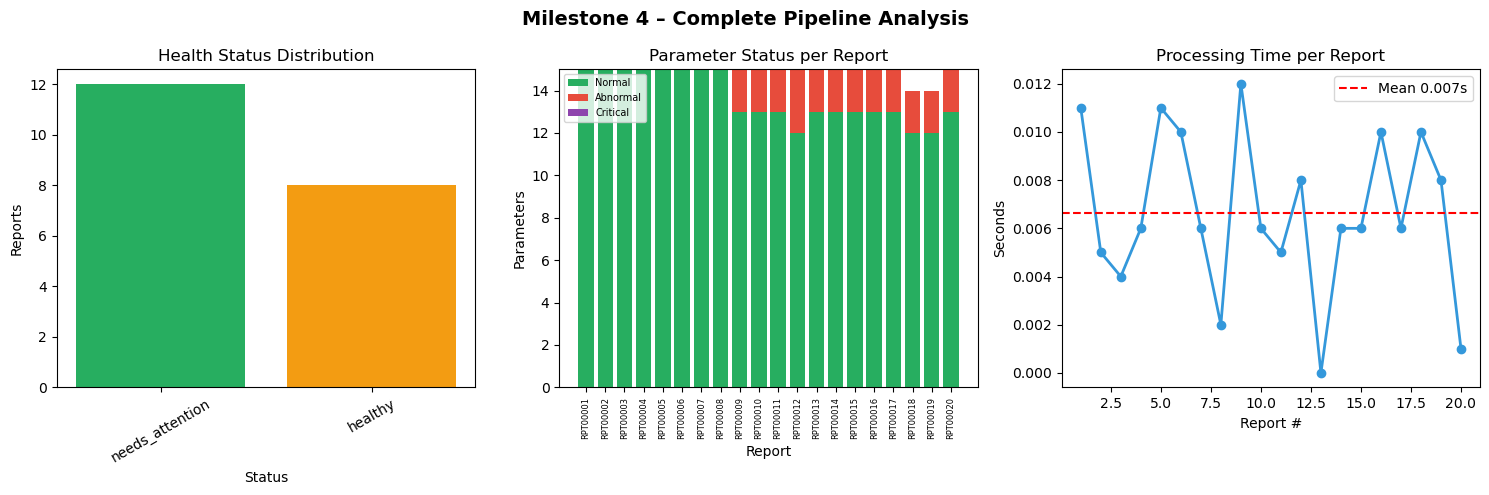

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Milestone 4 – Complete Pipeline Analysis',
             fontsize=14, fontweight='bold')

# Chart 1 – Status distribution
sc = df['overall_status'].value_counts()
axes[0].bar(sc.index, sc.values,
            color=['#27ae60','#f39c12','#e74c3c','#2980b9','#e67e22'][:len(sc)])
axes[0].set_title('Health Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Reports')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2 – Parameter breakdown (stacked)
axes[1].bar(df['report_id'], df['normal'],    label='Normal',    color='#27ae60')
axes[1].bar(df['report_id'], df['abnormal'],  label='Abnormal',  color='#e74c3c',
            bottom=df['normal'])
axes[1].bar(df['report_id'], df['critical'],  label='Critical',  color='#8e44ad',
            bottom=df['normal']+df['abnormal'])
axes[1].set_title('Parameter Status per Report')
axes[1].set_xlabel('Report')
axes[1].set_ylabel('Parameters')
axes[1].legend(fontsize=7)
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

# Chart 3 – Processing time
axes[2].plot(range(1, len(df)+1), df['processing_time'],
             marker='o', color='#3498db', linewidth=2)
axes[2].axhline(y=df['processing_time'].mean(), color='red',
                linestyle='--', label=f"Mean {df['processing_time'].mean():.3f}s")
axes[2].set_title('Processing Time per Report')
axes[2].set_xlabel('Report #')
axes[2].set_ylabel('Seconds')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/milestone4_analysis.png', dpi=200, bbox_inches='tight')
print("✓ Chart saved → outputs/milestone4_analysis.png")
plt.show()